# bearing-datasets: a guided tour

This notebook is written for someone who has **never used the library**. Read it top to
bottom and run each cell; every step explains what it does and why.

**What the library does.** Public bearing datasets (CWRU, Paderborn, ...) come in very
different formats: `.mat` files with nested structs, CSVs, archives, different label names.
`bearing-datasets` downloads each one from its original source and converts it **once** into
the same simple format, so all datasets are used the same way.

**Four words to know**

| word | meaning | example |
|---|---|---|
| *root* | folder where the converted datasets live (can be shared by a team) | `/data/bearing_datasets` |
| *recording* | one acquisition: the machine ran in some condition and several sensors were recorded **at the same time** | `12k_DE_IR007_1` |
| *signal* | **one** channel of one recording: a 1-D numpy array, read with `ds.signal(signal_id)` | `12k_DE_IR007_1/DE` |
| *metadata* | a table with **one row per signal**, describing it (condition, sensor, speed, ...) | `ds.metadata()` |

**The whole API you need**

| code | returns |
|---|---|
| `bd.list_datasets()` | names of the available datasets |
| `ds = bd.open("cwru")` | a dataset (nothing is loaded yet) |
| `ds.metadata()` | the metadata table (pandas DataFrame) |
| `ds.columns()` | what every column of the table means |
| `ds.signal(signal_id)` | one signal (numpy array) |
| `ds.recording(recording_id)` | all channels of one recording (dict of arrays) |
| `ds.iter_signals(signal_ids)` | signals one by one (to process big datasets) |
| `bd.load_metadata([...])` | the metadata of several datasets in one table |
| `ds.cite()` | how to cite the dataset |

The datasets must be **built** once per folder (download + conversion) with the command line,
e.g. `bearing-datasets --root /data/bearing_datasets build cwru`. If `bd.open` says a
dataset is not built, ask whoever manages the server or run that command.

## 0. Setup

**Before you start**, build the datasets this notebook uses (about 8 GB of downloads, once
per datasets folder), in a terminal:

```bash
bearing-datasets build cwru hust ottawa_uored paderborn ims
```

Only CWRU is needed for sections 1-5; Paderborn for section 6, the first four for section 7,
and IMS for section 8.

The library needs to know the folder where the datasets are. Save it **once** (it is remembered for your user, on Linux, macOS and Windows) with `bd.set_root(folder)` or, in a terminal, `bearing-datasets root <folder>`. `bd.get_root()` shows the folder in use and where the setting comes from.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

import bearing_datasets as bd

pd.set_option("display.max_colwidth", 120)

# bd.set_root("/data/bearing_datasets")   # run once if the folder is not set yet
folder, source = bd.get_root()
print(f"datasets folder: {folder}  (from {source})")
print(len(bd.list_datasets()), "datasets in the package, e.g.", bd.list_datasets()[:4])

datasets folder: /tmp/bearing_datasets  (from $BEARING_DATASETS_ROOT)
69 datasets in the package, e.g. ['adelaide', 'arkansas', 'army_pla', 'bjtu_bogie']


The command line gives the details of one dataset: description, source, size, **license** and citation (the `!` runs a shell command from the notebook; `bearing-datasets list` shows which datasets are built):

In [2]:
!bearing-datasets info cwru

cwru: Case Western Reserve University bearing data center
license: unspecified (public, cite CWRU)
size: download 0.69 GB, built 0.16 GB (measured)
sources: http

Seeded (EDM) single-point faults of 0.007"-0.028" on the drive-end (DE) or
fan-end (FE) bearing of a 2 hp motor, loads 0-3 hp (1797-1720 rpm).
Accelerometers at the DE and FE bearing housings and on the base plate (BA),
12 kHz or 48 kHz. One recording per .mat file (161 files from the 4 official
index pages). Normal baseline files have no BA channel. The bearing_id of a
fault is shared by the 4 loads recorded with the same damaged bearing, so
grouped splits can keep a physical bearing on one side.
Bearing fault frequencies are in bpfo, bpfi, bsf, ftf (DE 6205-2RS, FE 6203-2RS),
from CWRU's bearing information page; its "rolling element" column is 2 x BSF
(4.7135 and 3.9874), stored here halved as the ball spin frequency.

Cite:
Case Western Reserve University Bearing Data Center,
https://engineering.case.edu/bearingdatacenter

## 1. Open a dataset and look at the metadata

`bd.open` only reads a small description file; no signal is loaded. `metadata()` returns a
normal **pandas DataFrame with one row per signal**, so everything you know about pandas
(filtering, `value_counts`, `groupby`, ...) works.

In [3]:
ds = bd.open("cwru")
print(ds)            # how many recordings and signals
meta = ds.metadata()
meta.head()

<Dataset cwru: 161 recordings, 411 signals>


,dataset,signal_id,recording_id,native_label,channel,sensor_location,fs,n_samples,condition,fault_location,...,load_unit,bearing_id,fault_origin,fault_size_mm,bpfo,bpfi,bsf,ftf,or_position,source_file
0,cwru,48k_Normal_0/DE,48k_Normal_0,Normal_0,DE,bearing_de,48000.0,243938,normal,none,...,hp,healthy,none,0.0,3.5848,5.4152,2.35675,0.39828,none,97.mat
1,cwru,48k_Normal_0/FE,48k_Normal_0,Normal_0,FE,bearing_fe,48000.0,243938,normal,none,...,hp,healthy,none,0.0,3.0530,4.9469,1.99370,0.38170,none,97.mat
2,cwru,48k_Normal_1/DE,48k_Normal_1,Normal_1,DE,bearing_de,48000.0,483903,normal,none,...,hp,healthy,none,0.0,3.5848,5.4152,2.35675,0.39828,none,98.mat
3,cwru,48k_Normal_1/FE,48k_Normal_1,Normal_1,FE,bearing_fe,48000.0,483903,normal,none,...,hp,healthy,none,0.0,3.0530,4.9469,1.99370,0.38170,none,98.mat
4,cwru,48k_Normal_2/DE,48k_Normal_2,Normal_2,DE,bearing_de,48000.0,485063,normal,none,...,hp,healthy,none,0.0,3.5848,5.4152,2.35675,0.39828,none,99.mat


Some columns exist in **every** dataset (`recording_id`, `channel`, `sensor_location`, `fs`,
`condition`, `fault_location`, ...); others only in the datasets that have the information
(e.g. `fault_size_mm` for CWRU). `ds.columns()` explains every column of this dataset.

There are **no missing values**: `none` means "does not apply" (e.g. the fault location of a
healthy machine) and `unknown` means "the dataset does not say".

In [4]:
print("missing values:", meta.isna().sum().sum())
ds.columns()

missing values: 0


,column,description
0,dataset,dataset name
1,signal_id,unique id of the signal (one channel of one recording)
2,recording_id,id of the acquisition; groups the channels recorded at the same time
3,native_label,label exactly as the dataset names it (to reproduce papers)
4,channel,channel name
5,sensor_location,"where the sensor is mounted (e.g. bearing_de, motor)"
6,fs,sampling rate in Hz
7,n_samples,number of samples
8,condition,"fault(s) in the machine, '+'-joined (see CONDITIONS)"
9,fault_location,"where the fault(s) are, in the order of condition; 'none' if normal"


A few typical questions answered with pandas:

In [5]:
# Which conditions are there, and how many signals of each?
meta.condition.value_counts()

condition
outer     203
inner     100
ball      100
normal      8
Name: count, dtype: int64

In [6]:
# How many drive-end signals per condition and sampling rate?
de = meta[meta.sensor_location == "bearing_de"]
de.pivot_table(index="condition", columns="fs", values="signal_id", aggfunc="count")

fs,12000.0,48000.0
condition,,
ball,28.0,12.0
inner,28.0,12.0
normal,NaN,4.0
outer,49.0,28.0


In [7]:
# Only the 12 kHz drive-end signals of inner-race faults, at 1 hp load
meta.query("sensor_location == 'bearing_de' and fs == 12000 and condition == 'inner' and load == 1")[
    ["signal_id", "native_label", "rpm", "fault_size_mm"]]

,signal_id,native_label,rpm,fault_size_mm
11,12k_DE_IR007_1/DE,IR007_1,1772.0,0.1778
111,12k_DE_IR014_1/DE,IR014_1,1774.0,0.3556
171,12k_DE_IR021_1/DE,IR021_1,1774.0,0.5334
271,12k_FE_IR021_1/DE,IR021_1,1776.0,0.5334
283,12k_FE_IR014_1/DE,IR014_1,1775.0,0.3556
295,12k_FE_IR007_1/DE,IR007_1,1732.0,0.1778
404,12k_DE_IR028_1/DE,IR028_1,1772.0,0.7112


## 2. Load signals

`signal(signal_id)` reads **one** signal from disk and returns a numpy array (in the
dtype of the original data). The sampling rate is in the `fs` column, which you need to build
a time axis.

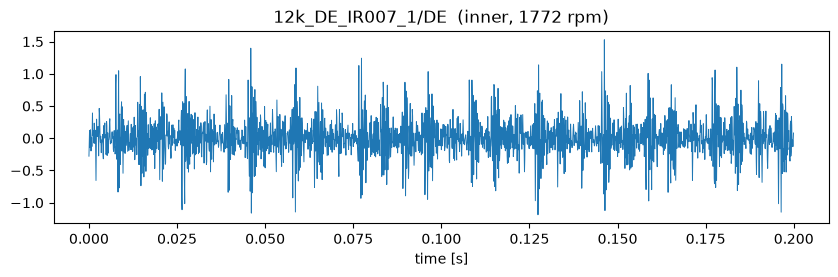

dtype: float64  samples: 121991  duration: 10.165916666666666 s


In [8]:
row = meta[meta.recording_id == "12k_DE_IR007_1"].iloc[0]    # one row of the metadata
x = ds.signal(row.signal_id)
t = np.arange(len(x)) / row.fs                                # time axis in seconds

fig, ax = plt.subplots(figsize=(10, 2.5))
ax.plot(t[:2400], x[:2400], lw=0.7)
ax.set(xlabel="time [s]", title=f"{row.signal_id}  ({row.condition}, {row.rpm:.0f} rpm)")
plt.show()
print("dtype:", x.dtype, " samples:", len(x), " duration:", len(x) / row.fs, "s")

`start` and `stop` (in samples) return only part of the signal:

In [9]:
first_second = ds.signal(row.signal_id, start=0, stop=int(row.fs))
first_second.shape

(12000,)

`recording()` returns **all channels recorded at the same time**, as a dict `{channel: array}`. For CWRU: the drive-end (DE), fan-end (FE) and base (BA) accelerometers.

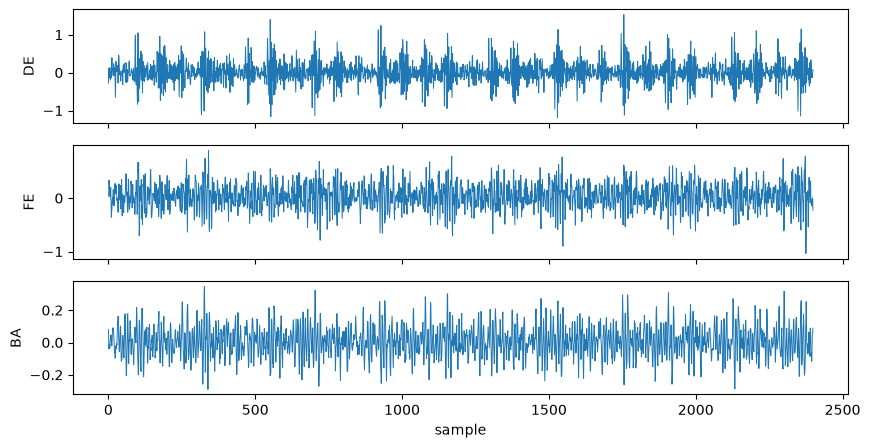

In [10]:
channels = ds.recording("12k_DE_IR007_1")
fig, axes = plt.subplots(len(channels), 1, figsize=(10, 5), sharex=True)
for ax, (name, sig) in zip(axes, channels.items()):
    ax.plot(sig[:2400], lw=0.7)
    ax.set_ylabel(name)
axes[-1].set_xlabel("sample")
plt.show()

## 3. Signals in a DataFrame

`with_signals(rows)` returns the metadata rows you pass (or all of them) with an extra
`signal` column: one numpy array per row. Select the rows first, so that only those signals
are read:

In [11]:
inner_de = ds.with_signals(meta[(meta.condition == "inner") & (meta.channel == "DE")])
inner_de[["signal_id", "condition", "fs", "signal"]].head()

,signal_id,condition,fs,signal
8,12k_DE_IR007_0/DE,inner,12000.0,"[-0.08300435129740519, -0.19573433133732535, 0.23341928143712576, 0.10395848303393214, -0.18111516966067864, 0.05555..."
11,12k_DE_IR007_1/DE,inner,12000.0,"[-0.2776016367265469, -0.04434479041916167, 0.11760303393213573, -0.14505457085828344, -0.111430499001996, 0.1309227..."
14,12k_DE_IR007_2/DE,inner,12000.0,"[-0.09323776447105789, 0.18728770459081834, 0.2176630738522954, 0.07017197604790419, 0.10038491017964071, 0.15658746..."
17,12k_DE_IR007_3/DE,inner,12000.0,"[0.2226985628742515, 0.09323776447105789, -0.1465164870259481, 0.1772167265469062, 0.248525748502994, -0.07114658682..."
20,48k_DE_IR007_0/DE,inner,48000.0,"[0.010016, -0.023788, -0.007929333333333333, 0.078876, 0.20282399999999998, 0.289212, 0.2725186666666667, 0.17486266..."


Everything you load must fit in memory: CWRU is small, but all of Paderborn takes more than 10 GB. `start`/`stop` keep only part of each signal, e.g. `ds.with_signals(rows, stop=4096)`.

The signals are also plain Parquet files (`signal_id`, `signal`), so any Parquet reader works without the package, e.g. polars (the `signal` column becomes a `List` column):

In [12]:
import polars as pl

pl_df = ds.metadata(backend="polars").join(
    pl.concat([pl.read_parquet(f) for f in ds.signal_files()]), on="signal_id")
pl_df.select("signal_id", "condition", "signal").head(3)

signal_id,condition,signal
str,str,list[f64]
"""48k_Normal_0/DE""","""normal""","[0.053197, 0.088662, … 0.046938]"
"""48k_Normal_0/FE""","""normal""","[0.145667, 0.097796, … 0.090195]"
"""48k_Normal_1/DE""","""normal""","[0.046104, -0.037134, … -0.070929]"


## 4. Labels: machine condition vs. sensor location

`condition` describes the **machine** (which faults exist) and `fault_location` says
**where** the faults are. A recording has several sensors, and only some of them sit on the
faulty bearing. Compare `fault_location` with `sensor_location` to know which ones:

In [13]:
meta[meta.recording_id == "12k_DE_IR007_1"][
    ["signal_id", "sensor_location", "condition", "fault_location"]]

,signal_id,sensor_location,condition,fault_location
11,12k_DE_IR007_1/DE,bearing_de,inner,bearing_de
12,12k_DE_IR007_1/FE,bearing_fe,inner,bearing_de
13,12k_DE_IR007_1/BA,base,inner,bearing_de


The FE and BA signals above say `condition = inner` even though their sensor is not on the faulty bearing. Depending on your study, keep only sensors on the faulty bearing (plus healthy machines):

In [14]:
on_fault = (meta.fault_location == meta.sensor_location) | (meta.condition == "normal")
meta[on_fault].groupby(["sensor_location", "condition"]).size().unstack(fill_value=0)

condition,ball,inner,normal,outer
sensor_location,,,,
bearing_de,28,28,4,56
bearing_fe,12,12,4,21


## 5. A windowed training set, split by bearing

Machine-learning models usually take fixed-length windows. `iter_signals()` yields one signal
at a time, so memory stays small even for large datasets.

Two things to get right:

* **Split before windowing, by physical bearing** (`bearing_id`). Windows of the same bearing
  are very similar; if some are in train and others in test, the test score is optimistic.
* **CWRU gotcha**: the normal baseline exists only at 48 kHz, so it is decimated to 12 kHz
  to match the 12 kHz fault data.

In [15]:
from scipy.signal import decimate

de = meta[meta.sensor_location == "bearing_de"]
subset = de[((de.fs == 12000) & (de.fault_location == "bearing_de")) | (de.condition == "normal")]
classes = {"normal": 0, "inner": 1, "outer": 2, "ball": 3}

window, X, y, groups = 2048, [], [], []
for (sid, sig), (_, row) in zip(ds.iter_signals(subset.signal_id), subset.iterrows()):
    if row.fs == 48000:
        sig = decimate(sig, 4)              # 48 kHz -> 12 kHz
    n = len(sig) // window                  # number of whole windows in this signal
    X.append(sig[: n * window].reshape(n, window))
    y += [classes[row.condition]] * n
    groups += [row.bearing_id] * n          # which physical bearing each window comes from

X, y, groups = np.concatenate(X), np.array(y), np.array(groups)
print("X:", X.shape, " windows per class:", np.bincount(y))

X: (3745, 2048)  windows per class: [ 206  944 1652  943]


In [16]:
# Grouped split: every bearing goes entirely to train or entirely to test
rng = np.random.default_rng(0)
bearings = np.unique(groups)
test_bearings = rng.choice(bearings, size=len(bearings) // 4, replace=False)
test = np.isin(groups, test_bearings)
print(f"{len(bearings)} bearings, {len(test_bearings)} in test")
print("train windows:", (~test).sum(), " test windows:", test.sum())

12 bearings, 3 in test
train windows: 2566  test windows: 1179


With scikit-learn, `GroupShuffleSplit` or `GroupKFold` with `groups=groups` do the same.

## 6. Channels with different sampling rates (Paderborn)

In Paderborn each recording has vibration and two motor currents at 64 kHz, force, speed and
torque at 4 kHz, and a temperature at 1 Hz. Each channel is its own row with its own `fs`,
so always take `fs` from the row of the signal you read.

In [17]:
pb = bd.open("paderborn")
pmeta = pb.metadata()
pmeta.groupby(["channel", "sensor_location", "fs"]).size()

channel          sensor_location  fs   
force            shaft            4000     2560
phase_current_1  motor            64000    2560
phase_current_2  motor            64000    2560
speed            shaft            4000     2560
temperature      bearing_module   1        2560
torque           shaft            4000     2560
vibration        bearing_module   64000    2560
dtype: int64

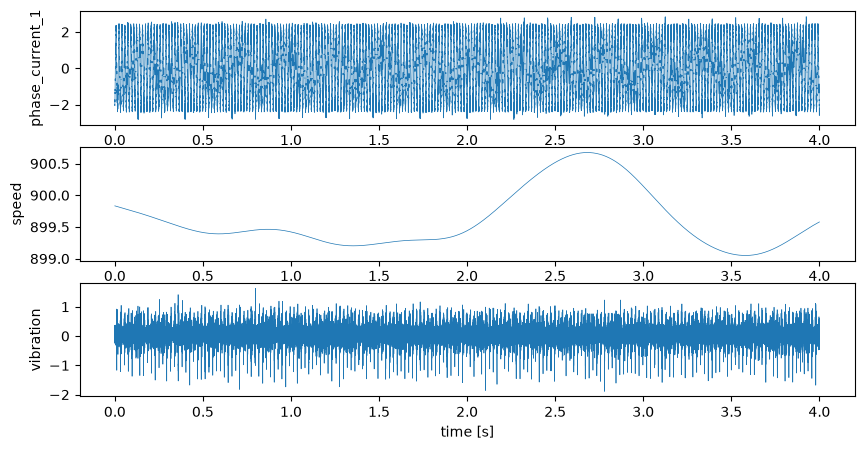

In [18]:
rec = pmeta[pmeta.bearing_id == "KA04"].recording_id.iloc[0]
signals = pb.recording(rec, channels=["vibration", "phase_current_1", "speed"])
fs = pmeta.set_index("signal_id").fs

fig, axes = plt.subplots(3, 1, figsize=(10, 5))
for ax, (name, sig) in zip(axes, signals.items()):
    t = np.arange(len(sig)) / fs[f"{rec}/{name}"]
    ax.plot(t, sig, lw=0.5)
    ax.set_ylabel(name)
axes[-1].set_xlabel("time [s]")
plt.show()

## 7. Working with several datasets

Because every dataset has the same core columns, you can put them in one table and treat
them the same way. This is what you need for cross-dataset studies (e.g. train on CWRU,
test on Paderborn: *domain adaptation*).

### 7.1 One table for all datasets

`bd.load_metadata([...])` concatenates the metadata of several datasets. It keeps only the
columns that **all** of them have, so the result has no missing values. The `dataset` column
tells where each row comes from.

In [19]:
names = ["cwru", "hust", "ottawa_uored", "paderborn"]
all_meta = bd.load_metadata(names)
print(all_meta.shape)
all_meta.columns.tolist()

(18610, 22)


['dataset',
 'signal_id',
 'recording_id',
 'native_label',
 'channel',
 'sensor_location',
 'fs',
 'n_samples',
 'condition',
 'fault_location',
 'signal_file',
 'signal_row_group',
 'signal_row',
 'quantity',
 'rpm',
 'load',
 'load_unit',
 'bearing_id',
 'bpfo',
 'bpfi',
 'bsf',
 'ftf']

Columns that only some datasets have (e.g. `bearing_id`, `load`) are dropped. To keep them, concatenate yourself and accept missing values for the other datasets:

In [20]:
with_extras = pd.concat([bd.open(n).metadata() for n in ["cwru", "paderborn"]], ignore_index=True)
with_extras[["dataset", "bearing_id", "load", "load_unit"]].drop_duplicates("dataset")

,dataset,bearing_id,load,load_unit
0,cwru,healthy,0.0,hp
411,paderborn,K001,0.7,Nm


### 7.2 An overview of the datasets

In [21]:
all_meta.groupby("dataset").agg(
    recordings=("recording_id", "nunique"),
    signals=("signal_id", "count"),
    channels=("channel", lambda c: sorted(c.unique())),
    sampling_rates=("fs", lambda f: sorted(f.unique())),
    rpm_range=("rpm", lambda r: (r.min(), r.max())),
)

,recordings,signals,channels,sampling_rates,rpm_range
dataset,,,,,
cwru,161,411,"[BA, DE, FE]","[12000.0, 48000.0]","(1718.0, 1798.0)"
hust,99,99,[vibration],[51200.0],"(1351.8000000000002, 1497.6000000000001)"
ottawa_uored,60,180,"[accelerometer, acoustic, temperature_difference]",[42000.0],"(1700.0, 2190.0)"
paderborn,2560,17920,"[force, phase_current_1, phase_current_2, speed, temperature, torque, vibration]","[1.0, 4000.0, 64000.0]","(900.0, 1500.0)"


In [22]:
# Which conditions does each dataset contain? (number of recordings)
all_meta.drop_duplicates(["dataset", "recording_id"]).pivot_table(
    index="condition", columns="dataset", values="recording_id", aggfunc="count", fill_value=0)

dataset,cwru,hust,ottawa_uored,paderborn
condition,,,,
ball,40,12,10,0
cage,0,0,10,0
inner,40,15,10,880
inner+ball,0,12,0,0
inner+outer,0,15,0,240
normal,4,15,20,480
outer,77,15,10,960
outer+ball,0,15,0,0


### 7.3 Select comparable data

Datasets differ in sensors and faults. A fair comparison needs the same kind of data, e.g.:

* accelerometers only (`quantity == "acceleration"`),
* on the faulty bearing, or on a healthy machine (as in section 4),
* single faults that all datasets share (`normal`, `inner`, `outer`, `ball`).

In [23]:
on_bearing = (all_meta.fault_location == all_meta.sensor_location) | (all_meta.condition == "normal")
selected = all_meta[
    (all_meta.quantity == "acceleration") & on_bearing
    & all_meta.condition.isin(["normal", "inner", "outer", "ball"])
]
selected.pivot_table(index="condition", columns="dataset", values="signal_id",
                     aggfunc="count", fill_value=0)

dataset,cwru,hust,ottawa_uored,paderborn
condition,,,,
ball,40,12,10,0
inner,40,15,10,880
normal,8,15,20,480
outer,77,15,10,960


Note that Paderborn has no `ball` faults: a classifier trained on the other datasets cannot be evaluated on that class there.

### 7.4 Read signals from several datasets

A signal is read through the dataset it belongs to. Keep one opened dataset per name and use
the `dataset` column to pick the right one:

In [24]:
datasets = {name: bd.open(name) for name in names}

row = selected.iloc[0]
x = datasets[row.dataset].signal(row.signal_id)
print(row.dataset, row.signal_id, x.shape)

cwru 48k_Normal_0/DE (243938,)


### 7.5 Compare the same fault across datasets

One inner-race recording per dataset, at a speed close to 1800 rpm. The **envelope spectrum**
(spectrum of the signal's amplitude) of a bearing fault shows peaks at the fault frequency.
Dividing the frequency axis by the shaft frequency (`rpm / 60`) gives **orders**, which makes
machines running at different speeds comparable. The red lines mark the inner-race fault
frequency and its harmonics, read from the `bpfi` column (in orders, like the x axis).

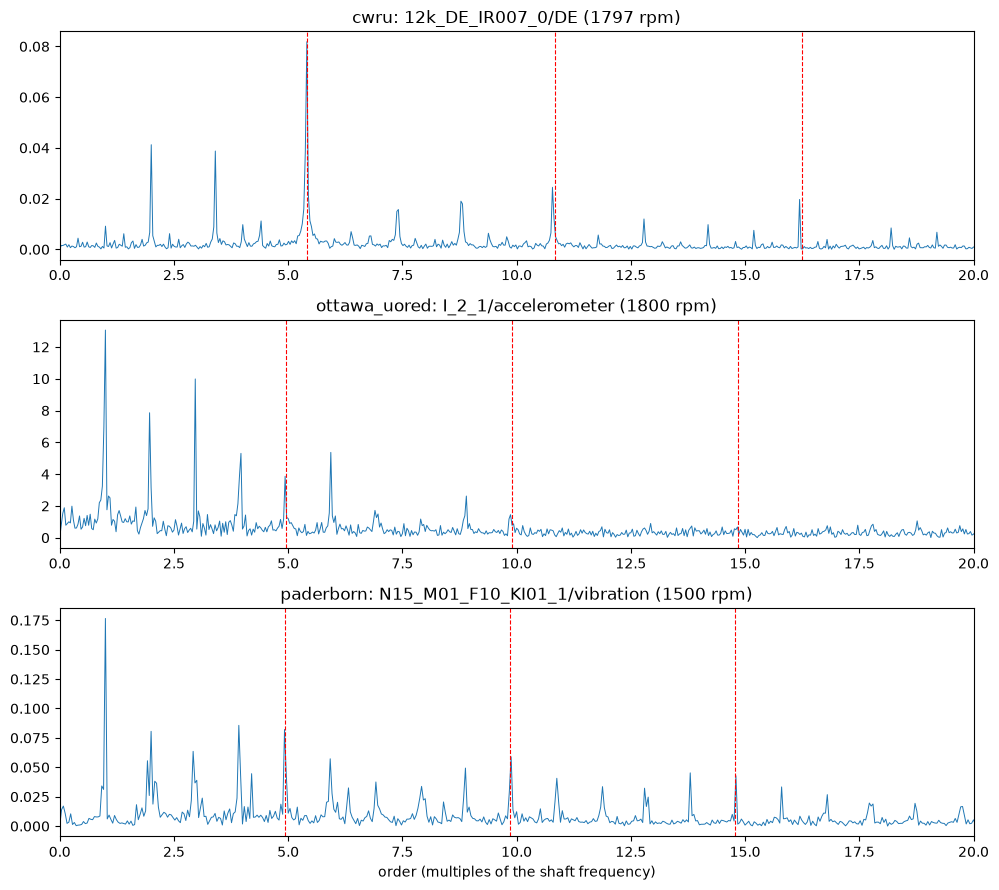

In [25]:
from scipy.signal import hilbert

compared = ["cwru", "ottawa_uored", "paderborn"]

fig, axes = plt.subplots(len(compared), 1, figsize=(10, 9))
for ax, name in zip(axes, compared):
    rows = selected[(selected.dataset == name) & (selected.condition == "inner")]
    row = rows.iloc[(rows.rpm - 1800).abs().argmin()]           # closest to 1800 rpm
    x = datasets[name].signal(row.signal_id, stop=int(row.fs))  # first second
    envelope = np.abs(hilbert(x - x.mean()))
    spectrum = np.abs(np.fft.rfft(envelope - envelope.mean())) / len(x)
    orders = np.fft.rfftfreq(len(x), 1 / row.fs) / (row.rpm / 60)
    ax.plot(orders, spectrum, lw=0.7)
    for k in (1, 2, 3):
        ax.axvline(k * row.bpfi, color="r", ls="--", lw=0.8)
    ax.set(xlim=(0, 20), title=f"{name}: {row.signal_id} ({row.rpm:.0f} rpm)")
axes[-1].set_xlabel("order (multiples of the shaft frequency)")
plt.tight_layout()
plt.show()

CWRU shows clear peaks at BPFI; the others are noisier. Real fault diagnosis usually band-pass filters the signal before the envelope, but that is beyond this tour.

### 7.6 A cross-dataset training set

Models need inputs of the same shape and meaning. Here every signal is

1. **resampled to a common rate** (12 kHz) with `scipy.signal.resample_poly`,
2. cut into windows of the same length (0.1 s = 1200 samples),
3. labelled with the same classes, and marked with its `domain` (the dataset).

To keep it quick, only 4 signals per dataset and class are used.

In [26]:
from fractions import Fraction

from scipy.signal import resample_poly

TARGET_FS, WINDOW = 12000, 1200
classes = {"normal": 0, "inner": 1, "outer": 2, "ball": 3}
sample = selected.groupby(["dataset", "condition"]).head(4)

X, y, domain = [], [], []
for _, row in sample.iterrows():
    x = datasets[row.dataset].signal(row.signal_id).astype(np.float64)
    ratio = Fraction(TARGET_FS, int(row.fs)).limit_denominator(1000)   # e.g. 3/16 for 64 kHz
    x = resample_poly(x, ratio.numerator, ratio.denominator)
    n = len(x) // WINDOW
    X.append(x[: n * WINDOW].reshape(n, WINDOW))
    y += [classes[row.condition]] * n
    domain += [row.dataset] * n

X, y, domain = np.concatenate(X), np.array(y), np.array(domain)
print("X:", X.shape)
class_names = {v: k for k, v in classes.items()}
pd.crosstab(pd.Series(domain, name="dataset"), pd.Series(y, name="class").map(class_names))

X: (5196, 1200)


class,ball,inner,normal,outer
dataset,,,,
cwru,405,405,300,406
hust,400,400,400,400
ottawa_uored,400,400,400,400
paderborn,0,160,160,160


In [27]:
# e.g. train on CWRU + HUST, test on Paderborn
train, test = np.isin(domain, ["cwru", "hust"]), domain == "paderborn"
print("train:", train.sum(), "windows   test:", test.sum(), "windows")

train: 3116 windows   test: 480 windows


Real studies also normalise the windows (e.g. per-window standardisation), because sensors and units differ between datasets (`unit` is often `unknown`).

### 7.7 Check the license and cite every dataset you use

Each dataset keeps the license of its authors: some forbid commercial use, some state no
license at all. Check it on the original page before using the data, and cite each dataset in
your paper or report (the citation shown is a suggestion; the source says what its authors ask
for):

In [28]:
used = sorted(set(domain))
for name in used:
    ds_ = datasets[name]
    print(f"--- {name}  (license: {ds_.manifest['license']})\n{ds_.cite().strip()}\n")

--- cwru  (license: unspecified (public, cite CWRU))
Case Western Reserve University Bearing Data Center,
https://engineering.case.edu/bearingdatacenter
Smith, W. A., & Randall, R. B. (2015). Rolling element bearing diagnostics using
the Case Western Reserve University data: A benchmark study. Mechanical Systems
and Signal Processing, 64-65, 100-131.

--- hust  (license: CC-BY-4.0)
Thuan, N. D., & Hong, H. S. (2023). HUST bearing: a practical dataset for ball
bearing fault diagnosis. BMC Research Notes, 16, 138. Data: Mendeley Data,
V3, doi:10.17632/cbv7jyx4p9.3

--- ottawa_uored  (license: CC-BY-4.0)
Sehri, M., & Dumond, P. (2023). University of Ottawa Rolling-element Dataset -
Vibration and Acoustic Faults under Constant Load and Speed conditions
(UORED-VAFCLS). Mendeley Data, V5, doi:10.17632/y2px5tg92h.5

--- paderborn  (license: CC-BY-NC-4.0)
Lessmeier, C., Kimotho, J. K., Zimmer, D., & Sextro, W. (2016). Condition
monitoring of bearing damage in electromechanical drive systems by

## 8. Run-to-failure data (prognostics)

In run-to-failure datasets (`ims`, `femto`, `xjtu_sy`) a bearing runs until it fails and a
short snapshot is recorded periodically. Each run has a `run_id`; each snapshot has
`time_s` (time since the start) and `rul_s` (remaining useful life: time left until the
last snapshot). The condition of each snapshot is `unknown`: what failed is known only at
the end (`failure`, `failed_bearing`).

Here, the vibration RMS of every snapshot of IMS test 2, where bearing 1 failed (outer race):

In [29]:
ims = bd.open("ims")
imeta = ims.metadata()
imeta.drop_duplicates("run_id")[["run_id", "failed_bearing", "failure"]]

,run_id,failed_bearing,failure
0,test1,bearing_3+bearing_4,bearing 3 inner race; bearing 4 roller element
17248,test2,bearing_1,bearing 1 outer race
21184,test3,bearing_3,bearing 3 outer race


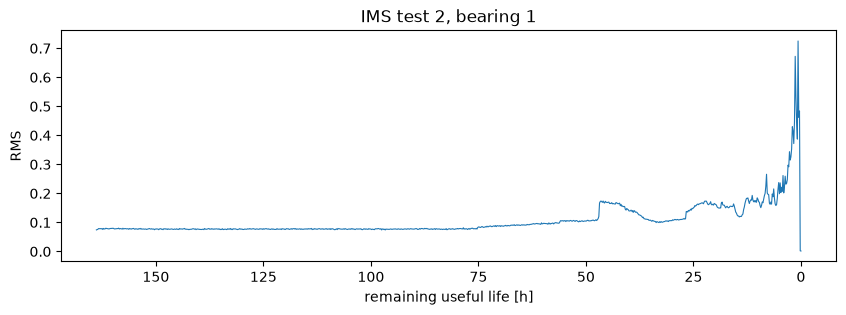

In [30]:
test2 = imeta[(imeta.run_id == "test2") & (imeta.channel == "bearing1")]
rms = [np.sqrt(np.mean(x**2)) for _, x in ims.iter_signals(test2.signal_id)]

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(test2.rul_s / 3600, rms, lw=0.8)
ax.invert_xaxis()                         # time runs to the right, toward the failure
ax.set(xlabel="remaining useful life [h]", ylabel="RMS", title="IMS test 2, bearing 1")
plt.show()

For prognostics, split by `run_id` (whole runs in train or test), never by snapshot.

## Where to go next

* `docs/guide.md`: concepts, recipes and answers to common questions (FAQ)
* `README.md`: installation, the list of datasets and the metadata columns
* `CONTRIBUTING.md`: how to add a new dataset, public or private (internal lab data such as
  the example in `examples/private_datasets/my_cwru`, which you use with `bd.open("my_cwru")`
  once built)
* `bearing-datasets info <name>`: details, license and citation of a dataset
* Using the library in a paper? Please cite it too (README, section *Citing*)
